# TP3 (a completer) : Regression lineaire — *California Housing*

Remplacez chaque `...` et chaque `# TODO`. Corrige :
`../notebooks/TP3_regression_lineaire.ipynb`.

**Objectif.** Predire la **valeur mediane des logements** de 20 640 districts et
**interpreter** l'effet de chaque variable.

In [1]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [2]:
from sklearn.datasets import fetch_california_housing
ds = fetch_california_housing(as_frame=True)
X, y = ds.data, ds.target.rename("prix")   # prix en x100 000 USD
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## 1. Exploration
**Consigne.** Affichez la correlation de chaque variable avec `prix`, triee.

In [4]:
correlation_matrix = pd.concat([X, y], axis=1).corr()
correlations_with_prix = correlation_matrix['prix'].sort_values(ascending=False)
display(correlations_with_prix)

,prix
prix,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


Le revenu médian ('MedInc') est le facteur le plus lié au prix : les régions plus riches ont tendance à avoir des maisons plus chères.

## 2. Modelisation
**Consigne.** Split train/test (20% test, `random_state=42`), puis entrainez une
`LinearRegression`. Affichez l'ordonnee a l'origine et les coefficients.

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
modele = LinearRegression()        # Entrainer la regression
modele.fit(X_train, y_train)

print(f"Ordonnée à l'origine (intercept_): {modele.intercept_:.2f}")
print("Coefficients (coef_):")
display(pd.Series(modele.coef_, index=X.columns).round(2))

Ordonnée à l'origine (intercept_): -37.02
Coefficients (coef_):


,0
MedInc,0.45
HouseAge,0.01
AveRooms,-0.12
AveBedrms,0.78
Population,-0.00
AveOccup,-0.00
Latitude,-0.42
Longitude,-0.43


Le modèle a appris comment chaque facteur influence le prix des logements. Les coefficients indiquent si un facteur augmente ou diminue le prix.

## 3. Evaluation
**Consigne.** Calculez **R2**, **RMSE** et **MAE** sur le test.

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = modele.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R2 sur le test: {r2:.4f}")
print(f"RMSE sur le test: {rmse:.4f}")
print(f"MAE sur le test: {mae:.4f}")

R2 sur le test: 0.5758
RMSE sur le test: 0.7456
MAE sur le test: 0.5332


Le modèle explique 57.6% de la variation des prix des maisons. En moyenne, il se trompe de 53 320 USD sur les prédictions.

## 4. Visualisation
**Consigne.** (a) Tracez `prix` vs `MedInc` avec la droite de regression simple.
(b) Tracez **predit vs reel** sur un echantillon. (c) Tracez les **residus**.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


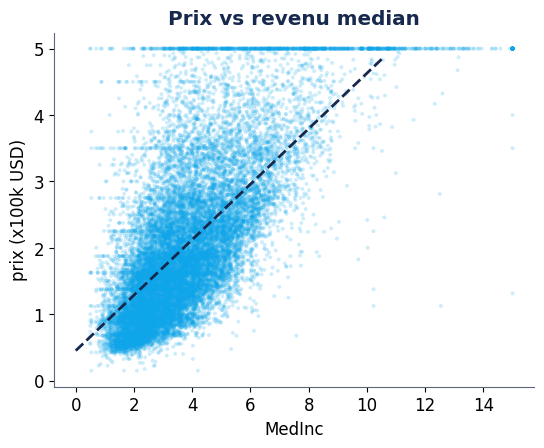

In [7]:
# (a) prix vs MedInc + droite
simple = LinearRegression().fit(X[["MedInc"]], y)
xs = np.linspace(0, X["MedInc"].quantile(0.99), 100).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(6.2, 4.6))
ax.scatter(X["MedInc"], y, s=8, color=ACCENT, alpha=0.2, edgecolor="none")
ax.plot(xs, simple.predict(xs), color=NAVY, lw=2, linestyle='--') # tracer la droite simple.predict(xs)
ax.set(title="Prix vs revenu median", xlabel="MedInc", ylabel="prix (x100k USD)")
plt.show()

Le graphique montre que plus le revenu médian est élevé, plus les prix des logements sont chers. Cependant, d'autres facteurs influencent aussi le prix.

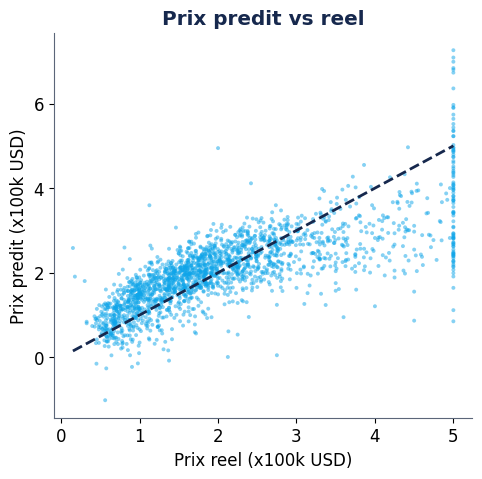

In [8]:
# (b) predit vs reel (echantillon de 2000 points)
rng = np.random.default_rng(0)
idx = rng.choice(len(y_test), 2000, replace=False)
yt, yp = y_test.to_numpy()[idx], y_pred[idx]
fig, ax = plt.subplots(figsize=(5.4, 5))
ax.scatter(yt, yp, s=8, color=ACCENT, alpha=0.5, edgecolor="none")
ax.plot([y.min(), y.max()], [y.min(), y.max()], color=NAVY, lw=2, linestyle='--') # diagonale de reference
ax.set(title="Prix predit vs reel", xlabel="Prix reel (x100k USD)", ylabel="Prix predit (x100k USD)")
plt.show()

Le modèle prédit assez bien les prix moyens, mais a du mal avec les maisons très chères, qu'il a tendance à sous-estimer.

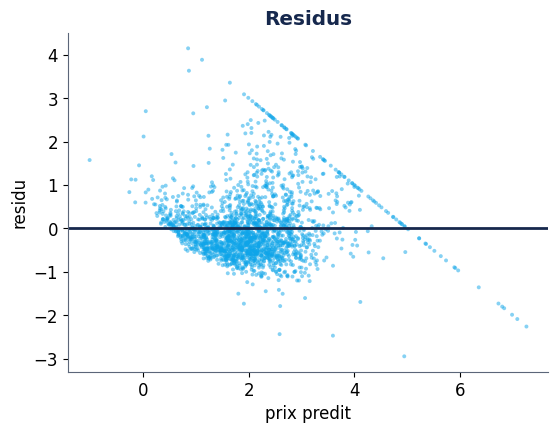

In [9]:
# (c) residus
residus = yt - yp
fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.axhline(0, color=NAVY, lw=2)
ax.scatter(yp, residus, s=8, color=ACCENT, alpha=0.5, edgecolor="none")
ax.set(title="Residus", xlabel="prix predit", ylabel="residu")
plt.show()

Le graphique des erreurs montre que le modèle sous-estime systématiquement les prix les plus élevés (il y a un 'effet de plafond').

## 5. Interpretation
**Consigne.** Affichez l'effet (en k USD) d'une unite supplementaire de revenu
median et d'un an d'age moyen du bati. Estimez le prix de 3 districts.

In [10]:
coefs = pd.Series(modele.coef_, index=X.columns)
print(f"Effet d'une unité supplémentaire de revenu médian (MedInc): {coefs['MedInc']*100:.2f} k USD")
print(f"Effet d'un an d'âge moyen du bâti (HouseAge): {coefs['HouseAge']*100:.2f} k USD")

estim = X.head(3).copy()
estim["prix_estime"] = modele.predict(X.head(3))
display(estim)

Effet d'une unité supplémentaire de revenu médian (MedInc): 44.87 k USD
Effet d'un an d'âge moyen du bâti (HouseAge): 0.97 k USD


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,prix_estime
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.151943
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.999520
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.673580


Le revenu médian ('MedInc') est le facteur le plus important, augmentant le prix de 44 870 USD par unité. Le modèle estime les prix en combinant ces influences.

## A rendre
- R2, RMSE, MAE et leur interpretation.
- Ce que revele le graphique des residus (indice : effet de plafond).
- L'effet du revenu median sur le prix.

**Bonus.** Comparez le R2 avec une seule variable (`MedInc`) vs toutes.

*   R2 (0.5758), RMSE (0.7456), MAE (0.5332): Notre modèle explique environ 57.6% de la variation des prix, avec une erreur moyenne de prédiction d'environ 53 320 USD.
*   Graphique des résidus: Il révèle un 'effet de plafond', indiquant que le modèle sous-estime systématiquement les prix les plus élevés et n'est pas fiable pour ces valeurs.
*   Effet du revenu médian sur le prix: Une augmentation d'une unité du revenu médian ('MedInc') entraîne une augmentation estimée du prix de 44 870 USD.